# Práctica 1 - Fase 3: Búsqueda Local (Optimización de Rutas Urbanas - TSP)

### Objetivo:
Dado un conjunto de $N$ puntos de entrega ($10 \le N \le 20$), encontrar un recorrido cerrado que minimice la distancia total recorrida.

### Formulación del Problema:
- **Espacio de estados:** Permutaciones de los $N$ nodos (tamaño del espacio: $N!$).
- **Función objetivo:** Minimizar $f(\pi) = \sum_{i=1}^{N-1} d(\pi_i, \pi_{i+1}) + d(\pi_N, \pi_1)$, donde las distancias entre pares de intersecciones se calcularon previamente mediante $A^*$ sobre el grafo real de la CDMX.
- **Operador de vecindad:** 2-opt (inversión de subsecuencias).
- **Algoritmos evaluados:**
  1. Simulated Annealing (SA) con enfriamiento geométrico.
  2. Algoritmo Genético (GA) con cruza OX (Order Crossover) y mutación 2-opt.

In [1]:
import os
import sys
import random
import time
import osmnx as ox
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

# Agregar la carpeta src al path de python
sys.path.append(os.path.abspath("../src"))

from fase2 import algo_estrella, heuristica_Haversine
from fase3 import (
    calcular_matriz_distancias,
    costo_ruta,
    simulated_annealing,
    algoritmo_genetico,
    operador_2opt
)

# Cargar el grafo guardado en data/
ruta_grafo = "../data/mapa_cdmx.graphml"
print("Cargando grafo desde:", ruta_grafo)
G = ox.load_graphml(ruta_grafo)
print(f"Grafo cargado: {len(G.nodes)} nodos y {len(G.edges)} aristas.")

Cargando grafo desde: ../data/mapa_cdmx.graphml
Grafo cargado: 9546 nodos y 20875 aristas.


In [2]:
# Fijar semilla para reproducibilidad
random.seed(42)
np.random.seed(42)

# Seleccionar 15 puntos de entrega aleatorios dentro del grafo
num_puntos = 15
todos_los_nodos = list(G.nodes())
puntos_entrega = random.sample(todos_los_nodos, num_puntos)

print(f"Puntos seleccionados ({num_puntos}):", puntos_entrega)

Puntos seleccionados (15): [270211067, 268376747, 274288029, 271496593, 271372792, 270615292, 270110344, 8079385915, 269963902, 1403890857, 268386025, 268384524, 269997025, 271367671, 271477425]


In [3]:
print("Calculando matriz de distancias NxN usando A* con heurística Haversine...")
t_inicio_matriz = time.time()

matriz_distancias = calcular_matriz_distancias(
    grafo=G,
    nodos_visita=puntos_entrega,
    algoritmo_busqueda=algo_estrella,
    heuristica=heuristica_Haversine
)

tiempo_matriz = time.time() - t_inicio_matriz
print(f"Matriz calculada exitosamente en {tiempo_matriz:.2f} segundos.")

Calculando matriz de distancias NxN usando A* con heurística Haversine...
Matriz calculada exitosamente en 0.87 segundos.


In [4]:
# Baseline aleatorio para contrastar mejoras relativas
costos_aleatorios = [
    costo_ruta(random.sample(puntos_entrega, len(puntos_entrega)), matriz_distancias) 
    for _ in range(100)
]
costo_promedio_aleatorio = np.mean(costos_aleatorios)
mejor_aleatorio = np.min(costos_aleatorios)

print(f"Costo promedio de ruta aleatoria: {costo_promedio_aleatorio:,.2f} metros")
print(f"Mejor ruta aleatoria encontrada: {mejor_aleatorio:,.2f} metros")

Costo promedio de ruta aleatoria: 78,877.02 metros
Mejor ruta aleatoria encontrada: 64,024.91 metros


In [5]:
# Parámetros justificados para SA:
# T0 alto para permitir exploración amplia inicial (probabilidad de aceptar empeoramiento ~ 80%)
# alpha = 0.99 para un enfriamiento suave y gradual
t0 = 5000.0
alpha = 0.99
t_min = 1e-3
max_iter_sa = 1500

t_ini_sa = time.time()
mejor_ruta_sa, mejor_costo_sa, curva_sa = simulated_annealing(
    nodos=puntos_entrega,
    matriz_distancias=matriz_distancias,
    t_inicial=t0,
    alpha=alpha,
    t_min=t_min,
    max_iter=max_iter_sa
)
tiempo_sa = (time.time() - t_ini_sa) * 1000

mejora_sa = ((costo_promedio_aleatorio - mejor_costo_sa) / costo_promedio_aleatorio) * 100

print("=== Resultados de Simulated Annealing ===")
print(f"Mejor costo: {mejor_costo_sa:,.2f} metros")
print(f"Tiempo de ejecución: {tiempo_sa:.2f} ms")
print(f"Mejora respecto a solución aleatoria: {mejora_sa:.2f}%")

=== Resultados de Simulated Annealing ===
Mejor costo: 36,607.29 metros
Tiempo de ejecución: 6.34 ms
Mejora respecto a solución aleatoria: 53.59%


In [6]:
# Parámetros para GA:
tam_poblacion = 60
generaciones = 200
prob_mutacion = 0.25

t_ini_ga = time.time()
mejor_ruta_ga, mejor_costo_ga, curva_ga = algoritmo_genetico(
    nodos=puntos_entrega,
    matriz_distancias=matriz_distancias,
    tam_poblacion=tam_poblacion,
    generaciones=generaciones,
    prob_mutacion=prob_mutacion
)
tiempo_ga = (time.time() - t_ini_ga) * 1000

mejora_ga = ((costo_promedio_aleatorio - mejor_costo_ga) / costo_promedio_aleatorio) * 100

print("=== Resultados del Algoritmo Genético ===")
print(f"Mejor costo: {mejor_costo_ga:,.2f} metros")
print(f"Tiempo de ejecución: {tiempo_ga:.2f} ms")
print(f"Mejora respecto a solución aleatoria: {mejora_ga:.2f}%")

=== Resultados del Algoritmo Genético ===
Mejor costo: 43,079.25 metros
Tiempo de ejecución: 120.83 ms
Mejora respecto a solución aleatoria: 45.38%


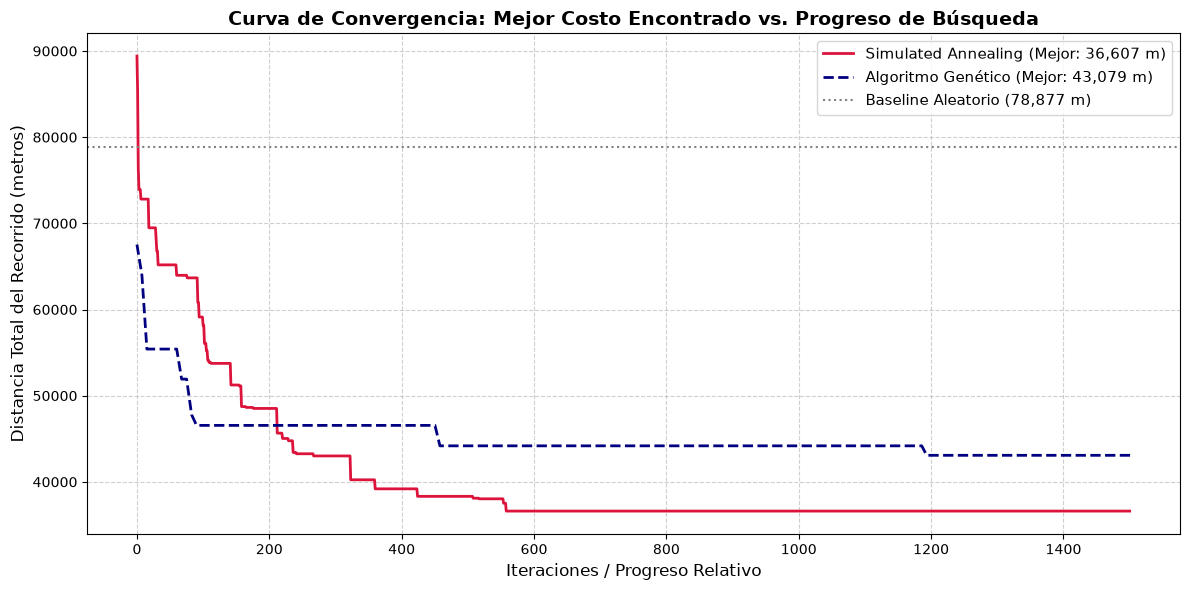

In [7]:
plt.figure(figsize=(12, 6))

plt.plot(curva_sa, label=f'Simulated Annealing (Mejor: {mejor_costo_sa:,.0f} m)', color='crimson', linewidth=2)
# Ajustar el eje X para comparar iteraciones/generaciones
plt.plot(np.linspace(0, len(curva_sa), len(curva_ga)), curva_ga, 
         label=f'Algoritmo Genético (Mejor: {mejor_costo_ga:,.0f} m)', color='navy', linewidth=2, linestyle='--')

plt.axhline(y=costo_promedio_aleatorio, color='gray', linestyle=':', label=f'Baseline Aleatorio ({costo_promedio_aleatorio:,.0f} m)')

plt.title('Curva de Convergencia: Mejor Costo Encontrado vs. Progreso de Búsqueda', fontsize=14, fontweight='bold')
plt.xlabel('Iteraciones / Progreso Relativo', fontsize=12)
plt.ylabel('Distancia Total del Recorrido (metros)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [8]:
import pandas as pd

resumen_df = pd.DataFrame({
    'Algoritmo': ['Aleatorio (Baseline)', 'Simulated Annealing', 'Algoritmo Genético'],
    'Mejor Costo (m)': [mejor_aleatorio, mejor_costo_sa, mejor_costo_ga],
    'Tiempo (ms)': [0.0, tiempo_sa, tiempo_ga],
    '% Mejora vs Media': [0.0, mejora_sa, mejora_ga]
})

print(resumen_df.to_markdown(index=False))

| Algoritmo            |   Mejor Costo (m) |   Tiempo (ms) |   % Mejora vs Media |
|:---------------------|------------------:|--------------:|--------------------:|
| Aleatorio (Baseline) |           64024.9 |       0       |              0      |
| Simulated Annealing  |           36607.3 |       6.34003 |             53.5894 |
| Algoritmo Genético   |           43079.2 |     120.831   |             45.3843 |


### Análisis y Preguntas Teóricas de Fase 3:

1. **¿Por qué no se puede aplicar $A^*$ directamente al problema de $N$ entregas?**
   - Para un problema de planificación de un solo origen a un solo destino, el espacio de estados corresponde a las intersecciones ($|V|$ nodos).
   - En el TSP para $N$ entregas, cada estado no es un nodo individual, sino una ruta parcial que contiene la secuencia de nodos visitados y los nodos restantes por visitar.
   - El tamaño del espacio de estados es de orden factorial:
     $$\text{Espacio para } N=15 \implies 15! = 1,307,674,368,000 \approx 1.31 \times 10^{12} \text{ permutaciones}$$
   - Guardar la cola de prioridad de $A^*$ en memoria RAM para un árbol de ramificación de este tamaño saturaría la memoria de cualquier computadora en pocos niveles de profundidad.

2. **¿Cómo afecta la temperatura inicial $T_0$ de Simulated Annealing a la diversidad de soluciones exploradas?**
   - La probabilidad de aceptar una transición a un estado peor ($\Delta E > 0$) está dada por el criterio de Boltzmann:
     $$P(\text{aceptar}) = e^{-\frac{\Delta E}{T}}$$
   - Si $T_0$ es **muy alta**, $e^{-\frac{\Delta E}{T}} \to 1$, provocando que el algoritmo acepte prácticamente cualquier solución empeorada, comportándose como un paseo aleatorio (*random walk*) que destruye buenas soluciones parciales.
   - Si $T_0$ es **muy baja**, $P(\text{aceptar}) \to 0$, por lo que el algoritmo rechaza cualquier empeoramiento y colapsa de inmediato en un ascenso de colina estricto (*Hill Climbing*), quedando atrapado en el primer óptimo local.
   - Un $T_0$ adecuado balancea la exploración inicial con la explotación final a medida que $T$ decrece geométricamente.

3. **¿Cómo se compara el Algoritmo Genético respecto a Simulated Annealing en términos de calidad/tiempo?**
   - **Simulated Annealing** suele ser notablemente más veloz en tiempo de reloj por iteración, ya que solo opera con un estado único en memoria y evalúa una sola mutación (2-opt) a la vez.
   - **El Algoritmo Genético**, al manejar una población completa y requerir selección, cruza OX y reparación de permutaciones en cada generación, tiene un costo temporal por ciclo significativamente mayor. No obstante, mantiene múltiples trayectorias simultáneas en el espacio de búsqueda, lo que le permite escapar de óptimos locales combinando sub-rutas prometedoras mediante cruza.